In [1]:
#Concept of a linear relationship

In [2]:
from statistics import linear_regression

from pandas import DataFrame

c = lambda f: 5/9 * (f-32)

In [6]:
temps = [(f, c(f)) for f in range(0, 101, 10)]

In [7]:
temps

[(0, -17.77777777777778),
 (10, -12.222222222222223),
 (20, -6.666666666666667),
 (30, -1.1111111111111112),
 (40, 4.444444444444445),
 (50, 10.0),
 (60, 15.555555555555557),
 (70, 21.11111111111111),
 (80, 26.666666666666668),
 (90, 32.22222222222222),
 (100, 37.77777777777778)]

In [8]:
import pandas as pd

In [17]:
temps_df = pd.DataFrame(temps, columns=['Fahrenheit', 'Celsius'])

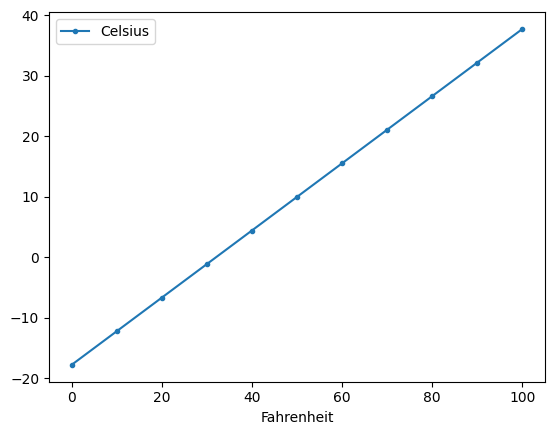

In [23]:
axes = temps_df.plot(x = 'Fahrenheit', y = 'Celsius', style = '.-')     #Cada punto será un . y una linea conectara cada punto

In [24]:
y_label = axes.set_ylabel('Celsius')

In [27]:
nyc = pd.read_csv('ave_hi_nyc_jan_1895-2018.csv')

In [29]:
nyc.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


In [30]:
nyc.tail()

,Date,Value,Anomaly
119,201401,35.5,-1.9
120,201501,36.1,-1.3
121,201601,40.8,3.4
122,201701,42.8,5.4
123,201801,38.7,1.3


In [31]:
nyc.columns = ['Date', 'Temperature', 'Anomaly']

In [32]:
nyc.head()

,Date,Temperature,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


In [34]:
nyc.Date.dtype

dtype('int64')

In [35]:
nyc.Date = nyc.Date.floordiv(100)       #floordiv performs integer division on every element of the Series. We eliminate 01 (month)

In [36]:
nyc.head()

,Date,Temperature,Anomaly
0,1895,34.2,-3.2
1,1896,34.7,-2.7
2,1897,35.5,-1.9
3,1898,39.6,2.2
4,1899,36.4,-1.0


In [40]:
nyc.Temperature.describe()

count    124.000000
mean      37.595161
std        4.539848
min       26.100000
25%       34.575000
50%       37.600000
75%       40.600000
max       47.600000
Name: Temperature, dtype: float64

In [43]:
from scipy import stats

In [44]:
linear_regression = stats.linregress(x=nyc.Date, y=nyc.Temperature)         #Calculate a regression line's slope and intercept. x is independent variables and y is dependent variables

In [45]:
linear_regression.slope

np.float64(0.014771361132966163)

In [46]:
linear_regression.intercept

np.float64(8.694993233674289)

In [47]:
linear_regression.slope*2019 + linear_regression.intercept  #y = mx + b where x is the year we want to know info, y is the temperature in x year

np.float64(38.51837136113297)

In [48]:
linear_regression.slope*1890 + linear_regression.intercept

np.float64(36.612865774980335)

In [49]:
import seaborn as sns

In [50]:
sns.set_style('whitegrid')

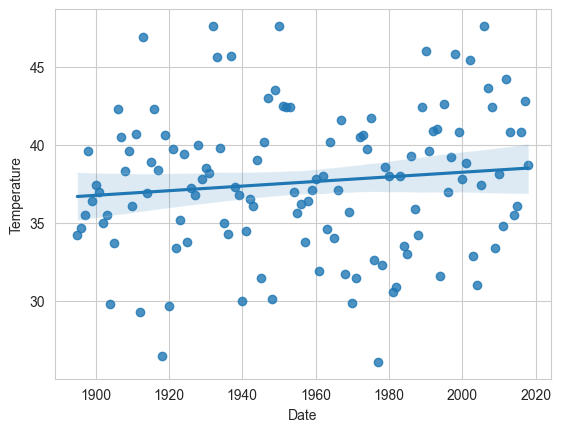

In [52]:
axes = sns.regplot(x=nyc.Date, y=nyc.Temperature)       #regplot create a scatter diagram

In [53]:
axes.set_ylim(10,70)

(10.0, 70.0)